In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Raw dataset eka load kirima
df = pd.read_csv('../data/raw/max_planck_weather_ts.csv')
print("Shape of the dataset:", df.shape)
df.head()

Shape of the dataset: (420551, 15)


,Date Time,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
0,01.01.2009 00:10:00,996.52,-8.02,265.40,-8.90,93.3,3.33,3.11,0.22,1.94,3.12,1307.75,1.03,1.75,152.3
1,01.01.2009 00:20:00,996.57,-8.41,265.01,-9.28,93.4,3.23,3.02,0.21,1.89,3.03,1309.80,0.72,1.50,136.1
2,01.01.2009 00:30:00,996.53,-8.51,264.91,-9.31,93.9,3.21,3.01,0.20,1.88,3.02,1310.24,0.19,0.63,171.6
3,01.01.2009 00:40:00,996.51,-8.31,265.12,-9.07,94.2,3.26,3.07,0.19,1.92,3.08,1309.19,0.34,0.50,198.0
4,01.01.2009 00:50:00,996.51,-8.27,265.15,-9.04,94.1,3.27,3.08,0.19,1.92,3.09,1309.00,0.32,0.63,214.3


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 420551 entries, 0 to 420550
Data columns (total 15 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   Date Time        420551 non-null  str    
 1   p (mbar)         420551 non-null  float64
 2   T (degC)         420551 non-null  float64
 3   Tpot (K)         420551 non-null  float64
 4   Tdew (degC)      420551 non-null  float64
 5   rh (%)           420551 non-null  float64
 6   VPmax (mbar)     420551 non-null  float64
 7   VPact (mbar)     420551 non-null  float64
 8   VPdef (mbar)     420551 non-null  float64
 9   sh (g/kg)        420551 non-null  float64
 10  H2OC (mmol/mol)  420551 non-null  float64
 11  rho (g/m**3)     420551 non-null  float64
 12  wv (m/s)         420551 non-null  float64
 13  max. wv (m/s)    420551 non-null  float64
 14  wd (deg)         420551 non-null  float64
dtypes: float64(14), str(1)
memory usage: 48.1 MB


In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
p (mbar),420551.0,989.212776,8.358481,913.60,984.20,989.58,994.72,1015.35
T (degC),420551.0,9.450147,8.423365,-23.01,3.36,9.42,15.47,37.28
Tpot (K),420551.0,283.492743,8.504471,250.60,277.43,283.47,289.53,311.34
Tdew (degC),420551.0,4.955854,6.730674,-25.01,0.24,5.22,10.07,23.11
rh (%),420551.0,76.008259,16.476175,12.95,65.21,79.30,89.40,100.00
VPmax (mbar),420551.0,13.576251,7.739020,0.95,7.78,11.82,17.60,63.77
VPact (mbar),420551.0,9.533756,4.184164,0.79,6.21,8.86,12.35,28.32
VPdef (mbar),420551.0,4.042412,4.896851,0.00,0.87,2.19,5.30,46.01
sh (g/kg),420551.0,6.022408,2.656139,0.50,3.92,5.59,7.80,18.13
H2OC (mmol/mol),420551.0,9.640223,4.235395,0.80,6.29,8.96,12.49,28.82


In [5]:
# Date Time column eka datetime format ekata hadaganima
df["Date Time"] = pd.to_datetime(df["Date Time"], format="%d.%m.%Y %H:%M:%S")

# Duplicate rows ain kirima
df = df.drop_duplicates().reset_index(drop=True)

# -9999 kiyana error values NaN (missing) widihata wenas kirima
sentinel_cols = ["wv (m/s)", "max. wv (m/s)"]
for c in sentinel_cols:
    df.loc[df[c] < -1, c] = np.nan

# Missing values (NaN) linear interpolation eken purawanna
df[sentinel_cols] = df[sentinel_cols].interpolate(method="linear", limit_direction="both")

print("Missing values remaining:")
print(df[sentinel_cols].isna().sum())

Missing values remaining:
wv (m/s)         0
max. wv (m/s)    0
dtype: int64


In [6]:
# Outliers hoyaganna IQR method eka hadaganima
def iqr_bounds(series, k=1.5):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    return q1 - k * iqr, q3 + k * iqr

outlier_cols = ["T (degC)", "p (mbar)"]
df_capped = df.copy()

# Outliers cap kirima (winsorize kirima)
for c in outlier_cols:
    lo, hi = iqr_bounds(df[c])
    df_capped[c] = df_capped[c].clip(lower=lo, upper=hi)

df = df_capped
print("Outlier handling complete (capped at IQR bounds).")

Outlier handling complete (capped at IQR bounds).


In [7]:
# 1. Date Time eken aluth features hadaganima
df["year"] = df["Date Time"].dt.year
df["month"] = df["Date Time"].dt.month
df["hour"] = df["Date Time"].dt.hour
df["day_of_year"] = df["Date Time"].dt.dayofyear

# 2. Wind vector components hadaganima (Circular-direction gataluwa wisadima)
wv_rad = df["wv (m/s)"]
wd_rad = df.pop("wd (deg)") * np.pi / 180

df["Wx"] = wv_rad * np.cos(wd_rad)
df["Wy"] = wv_rad * np.sin(wd_rad)

max_wv_rad = df["max. wv (m/s)"]
df["max_Wx"] = max_wv_rad * np.cos(wd_rad)
df["max_Wy"] = max_wv_rad * np.sin(wd_rad)

# Aluth columns tika balamu
df[["Wx", "Wy", "max_Wx", "max_Wy", "hour", "month"]].head()

,Wx,Wy,max_Wx,max_Wy,hour,month
0,-0.911955,0.478787,-1.549439,0.813474,0,1
1,-0.518797,0.499249,-1.080827,1.040103,0,1
2,-0.187962,0.027756,-0.623242,0.092032,0,1
3,-0.323359,-0.105066,-0.475528,-0.154508,0,1
4,-0.264351,-0.180328,-0.520442,-0.355021,0,1


In [8]:
from sklearn.preprocessing import LabelEncoder

# Masaya anuwa ruthuwa (season) hoyaganna function eka
def month_to_season(m):
    if m in (12, 1, 2):
        return "Winter"
    elif m in (3, 4, 5):
        return "Spring"
    elif m in (6, 7, 8):
        return "Summer"
    else:
        return "Autumn"

# Welaawa anuwa dawase kaalaya hoyaganna function eka
def hour_to_bucket(h):
    if 5 <= h < 12:
        return "Morning"
    elif 12 <= h < 17:
        return "Afternoon"
    elif 17 <= h < 21:
        return "Evening"
    else:
        return "Night"

df["season"] = df["month"].apply(month_to_season)
df["time_of_day"] = df["hour"].apply(hour_to_bucket)

# Season eka One-hot encode kirima
season_dummies = pd.get_dummies(df["season"], prefix="season")
df = pd.concat([df, season_dummies], axis=1)

# Time of day eka Label encode kirima
le = LabelEncoder()
df["time_of_day_encoded"] = le.fit_transform(df["time_of_day"])
print(dict(zip(le.classes_, le.transform(le.classes_))))

df[["season", "time_of_day", "time_of_day_encoded"] + list(season_dummies.columns)].head()

{'Afternoon': np.int64(0), 'Evening': np.int64(1), 'Morning': np.int64(2), 'Night': np.int64(3)}


,season,time_of_day,time_of_day_encoded,season_Autumn,season_Spring,season_Summer,season_Winter
0,Winter,Night,3,False,False,False,True
1,Winter,Night,3,False,False,False,True
2,Winter,Night,3,False,False,False,True
3,Winter,Night,3,False,False,False,True
4,Winter,Night,3,False,False,False,True


In [9]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# Scale karanna one columns tika thoraganima
feature_cols = ["p (mbar)", "T (degC)", "rh (%)", "VPdef (mbar)", "sh (g/kg)", "Wx", "Wy"]

# StandardScaler eka pawichi kirima (Zero mean, unit variance)
scaler_std = StandardScaler()
df_std_scaled = pd.DataFrame(scaler_std.fit_transform(df[feature_cols]),
                              columns=[c + "_std" for c in feature_cols])

# MinMaxScaler eka pawichi kirima (0 saha 1 athara agayanta genima)
scaler_mm = MinMaxScaler()
df_mm_scaled = pd.DataFrame(scaler_mm.fit_transform(df[feature_cols]),
                             columns=[c + "_mm" for c in feature_cols])

# Scale karapu columns tika original dataset ekata ekathu kirima
df = pd.concat([df.reset_index(drop=True), df_std_scaled, df_mm_scaled], axis=1)

# Scale wunu aluth columns wala mulinma thiyena data tika balamu
df[[c + "_std" for c in feature_cols] + [c + "_mm" for c in feature_cols]].head()

,p (mbar)_std,T (degC)_std,rh (%)_std,VPdef (mbar)_std,sh (g/kg)_std,Wx_std,Wy_std,p (mbar)_mm,T (degC)_mm,rh (%)_mm,VPdef (mbar)_mm,sh (g/kg)_mm,Wx_mm,Wy_mm
0,0.891497,-2.079707,1.049258,-0.780210,-1.536687,-0.144306,0.571729,0.667498,0.139876,0.923033,0.004782,0.081679,0.285408,0.559914
1,0.897657,-2.126141,1.055334,-0.782254,-1.555512,0.053308,0.584920,0.668685,0.131818,0.924182,0.004564,0.078843,0.295362,0.561136
2,0.892729,-2.138047,1.085709,-0.784299,-1.559277,0.219595,0.280977,0.667735,0.129752,0.929925,0.004347,0.078276,0.303737,0.532983
3,0.890265,-2.114235,1.103935,-0.786343,-1.544217,0.151541,0.195355,0.667260,0.133884,0.933372,0.004130,0.080545,0.300309,0.525053
4,0.890265,-2.109472,1.097860,-0.786343,-1.544217,0.181200,0.146837,0.667260,0.134711,0.932223,0.004130,0.080545,0.301803,0.520559


In [10]:
from sklearn.decomposition import PCA

# Eka wage thiyena humidity columns tika thoraganima
corr_group = ["rh (%)", "VPmax (mbar)", "VPact (mbar)", "VPdef (mbar)", "sh (g/kg)", "H2OC (mmol/mol)"]

# PCA apply kirima (columns 2kata adu kirima)
pca = PCA(n_components=2)
pca_result = pca.fit_transform(StandardScaler().fit_transform(df[corr_group]))

# Aluth columns 2ka dataset ekata ekathu kirima
df["humidity_pc1"] = pca_result[:, 0]
df["humidity_pc2"] = pca_result[:, 1]

print("PCA complete. Added humidity_pc1 and humidity_pc2.")

PCA complete. Added humidity_pc1 and humidity_pc2.


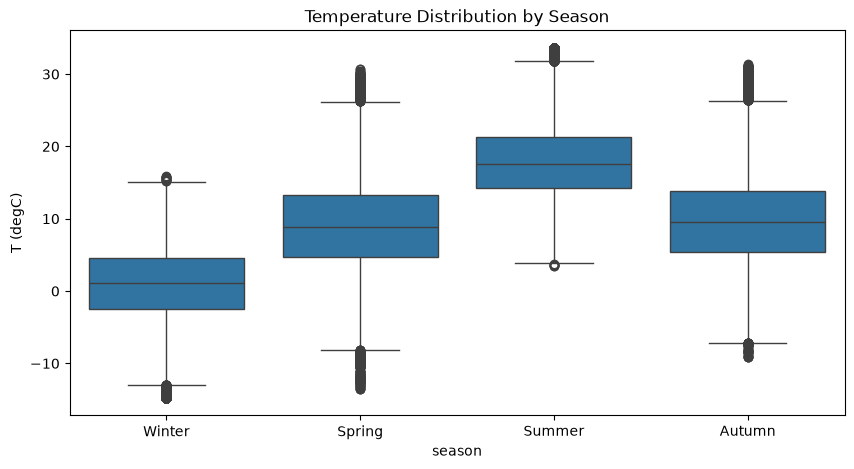

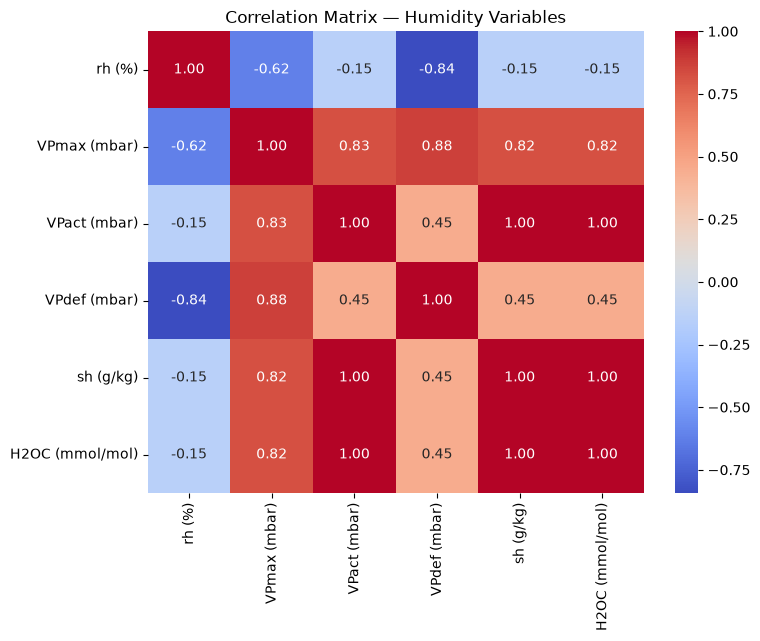

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

# Chart 1: Ushnathwaya (Temperature) Ruthuwa (Season) anuwa wenas wena widiha
plt.figure(figsize=(10, 5))
season_order = ["Winter", "Spring", "Summer", "Autumn"]
sns.boxplot(data=df, x="season", y="T (degC)", order=season_order)
plt.title("Temperature Distribution by Season")
# plt.savefig('results/eda_visualizations/temperature_by_season.png') # Chart eka save karanna one nam meka pawichi karanna
plt.show()

# Chart 2: Humidity variables athara thiyena sambandathawaya (Correlation)
corr_group = ["rh (%)", "VPmax (mbar)", "VPact (mbar)", "VPdef (mbar)", "sh (g/kg)", "H2OC (mmol/mol)"]
plt.figure(figsize=(8, 6))
sns.heatmap(df[corr_group].corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Matrix — Humidity Variables")
# plt.savefig('results/eda_visualizations/correlation_matrix.png') # Chart eka save karanna one nam meka pawichi karanna
plt.show()

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. Data Leakage wena columns ain kirima saha X, y wen kirima
leak_cols = ["T (degC)", "T (degC)_std", "T (degC)_mm", "Date Time",
             "Tpot (K)", "Tdew (degC)",
             "rh (%)", "rh (%)_std", "rh (%)_mm",
             "VPmax (mbar)", "VPact (mbar)", "VPdef (mbar)", "VPdef (mbar)_std", "VPdef (mbar)_mm",
             "sh (g/kg)", "sh (g/kg)_std", "sh (g/kg)_mm", "H2OC (mmol/mol)",
             "humidity_pc1", "humidity_pc2", "season", "time_of_day"]

X = df.drop(columns=leak_cols)
X = X.select_dtypes(include=[np.number]) # Ilakkam thiyena columns witharak ganna
y = df["T (degC)"]

# 2. Train saha Test sets widihata data 80% - 20% anupathayen kadima
# Viva eke code eka ikmanin run wenna data row 40,000k witharak sample ekak widihata gannawa
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train_sample = X_train.sample(n=40000, random_state=42)
y_train_sample = y_train.loc[X_train_sample.index]

# 3. Random Forest Model eka hadima saha train kirima
rf_model = RandomForestRegressor(n_estimators=30, max_depth=12, random_state=42, n_jobs=-1)
rf_model.fit(X_train_sample, y_train_sample)

# 4. Model eke performance manima (Evaluation Metrics)
y_pred = rf_model.predict(X_test)
print("Random Forest Model Evaluation:")
print(f"MAE (Mean Absolute Error): {mean_absolute_error(y_test, y_pred):.3f}")
print(f"RMSE (Root Mean Squared Error): {np.sqrt(mean_squared_error(y_test, y_pred)):.3f}")
print(f"R^2 Score: {r2_score(y_test, y_pred):.4f}")

Random Forest Model Evaluation:
MAE (Mean Absolute Error): 0.154
RMSE (Root Mean Squared Error): 0.226
R^2 Score: 0.9993


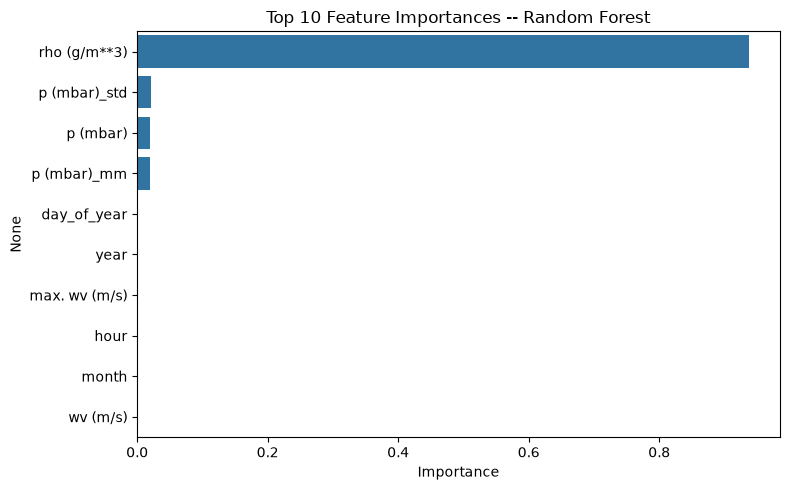

In [13]:
# Feature importances chart eka hadima
importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False).head(10)

plt.figure(figsize=(8, 5))
sns.barplot(x=importances.values, y=importances.index)
plt.title("Top 10 Feature Importances -- Random Forest")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

In [14]:
from sklearn.model_selection import GridSearchCV

# 1. Test karanna one parameters layaistuwa (Hyperparameter Grid)
param_grid = {
    'n_estimators': [30, 50],
    'max_depth': [10, 15]
}

# 2. GridSearchCV eka setup kirima
grid_search = GridSearchCV(estimator=RandomForestRegressor(random_state=42),
                           param_grid=param_grid,
                           cv=3,
                           scoring='neg_mean_absolute_error',
                           n_jobs=-1)

# 3. Tuning eka run kirima (Train data sample ekata)
print("Starting GridSearchCV... Please wait.")
grid_search.fit(X_train_sample, y_train_sample)

# 4. Hondama parameters saha aluth model eka ganeema
best_rf_model = grid_search.best_estimator_
print("Best Hyperparameters:", grid_search.best_params_)

# 5. Aluth (tuned) model eken predict karala metrics ganeema
y_pred_tuned = best_rf_model.predict(X_test)
print("\nTuned Random Forest Model Evaluation:")
print(f"MAE: {mean_absolute_error(y_test, y_pred_tuned):.3f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_tuned)):.3f}")
print(f"R^2 Score: {r2_score(y_test, y_pred_tuned):.4f}")

Starting GridSearchCV... Please wait.
Best Hyperparameters: {'max_depth': 15, 'n_estimators': 50}

Tuned Random Forest Model Evaluation:
MAE: 0.139
RMSE: 0.212
R^2 Score: 0.9994


   Actual_Temperature_degC  Predicted_Temperature_degC
0                     3.46                    3.351777
1                    19.21                   19.025260
2                    21.48                   21.699670
3                    15.60                   15.622429
4                    22.27                   22.178089
5                     4.45                    3.815623
6                    -2.96                   -2.992994
7                    15.62                   15.890769
8                    14.08                   13.986560
9                     5.19                    5.244944
\nPredictions hariyata save wuna: '../results/outputs/rf_predictions.csv'


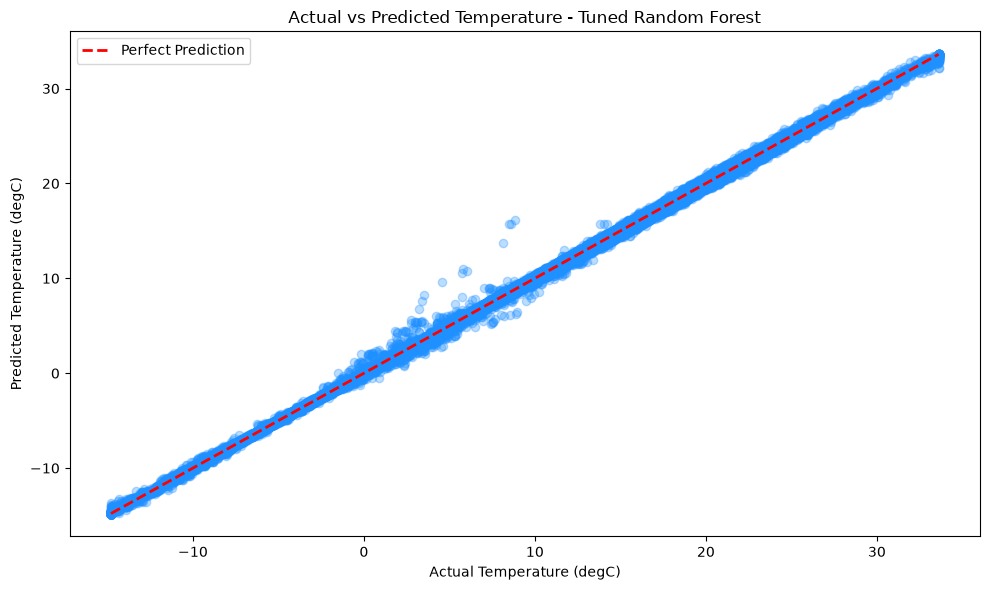

In [15]:
# 1. Actual values saha Predicted values ekathu karala DataFrame ekak hadima
results_df = pd.DataFrame({
    'Actual_Temperature_degC': y_test.values,
    'Predicted_Temperature_degC': y_pred_tuned
})

# Mul data row 10 pennima
print(results_df.head(10))

# 2. Output eka CSV file ekak widihata save kirima (results/outputs folder ekata)
results_df.to_csv('../results/outputs/rf_predictions.csv', index=False)
print("\\nPredictions hariyata save wuna: '../results/outputs/rf_predictions.csv'")

# 3. Actual vs Predicted values pennana graph eka (Viva ekata wadagath)
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_tuned, alpha=0.3, color='dodgerblue')

# Hariytama predict wuna nam data thiyenna one rathu ira
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')

plt.xlabel('Actual Temperature (degC)')
plt.ylabel('Predicted Temperature (degC)')
plt.title('Actual vs Predicted Temperature - Tuned Random Forest')
plt.legend()
plt.tight_layout()

# Graph eka save karanna one nam yata line eke '#' eka ain karanna
# plt.savefig('../results/eda_visualizations/actual_vs_predicted_rf.png')

plt.show()

In [16]:
# 1. Apita predict karanna one dawasa saha welawa thoraganna (Udaharanayak: 2015 Jan 1, dawal 12:00)
target_time = "2015-02-01 12:00:00"

# 2. E welawata adala data row eka original dataset (df) eken wen karaganeema
single_reading = df[df["Date Time"] == target_time]

# E welawata adala data ekak dataset eke thiyenawada kiyala check kirima
if not single_reading.empty:
    # 3. Aththa ushnathwaya wenama aragena thiyagamu (compare karanna)
    actual_temp = single_reading["T (degC)"].values[0]
    
    # 4. Model ekata danna one features (X) tika wen karaganima (Leak columns ain kirima)
    X_single = single_reading.drop(columns=leak_cols).select_dtypes(include=[np.number])
    
    # 5. Tuned Random Forest model eka pawichi karala predict kirima
    predicted_temp = best_rf_model.predict(X_single)[0]
    
    # 6. Prathipalaya (Output eka) print kirima
    print(f"Date and Time    : {target_time}")
    print(f"Actual Temp      : {actual_temp:.2f} °C")
    print(f"Predicted Temp   : {predicted_temp:.2f} °C")
    
    # Waradda (Error) eka balamu
    error = abs(actual_temp - predicted_temp)
    print(f"Prediction Error : {error:.3f} °C")
else:
    print("Oya dila thiyena welawata adala data dataset eke naha. Wena welawak denna.")

Date and Time    : 2015-02-01 12:00:00
Actual Temp      : -0.41 °C
Predicted Temp   : -0.12 °C
Prediction Error : 0.290 °C


In [17]:
# 1. Model eka hadima (n_estimators=100 dila thawat wadi diyunu karala thiyenawa)
print("Mulu dataset ekama train wemina pawathi. Karunakara randei sitinna...")
full_rf_model = RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)

# 2. Mulu Train data ekama (X_train, y_train) pawichi karala train kirima
full_rf_model.fit(X_train, y_train)

# 3. Test data walin predict karala aluth error eka balima
y_pred_full = full_rf_model.predict(X_test)

print("\nFull Dataset Random Forest Model Evaluation:")
print(f"MAE (Mean Absolute Error): {mean_absolute_error(y_test, y_pred_full):.3f}")
print(f"RMSE (Root Mean Squared Error): {np.sqrt(mean_squared_error(y_test, y_pred_full)):.3f}")
print(f"R^2 Score: {r2_score(y_test, y_pred_full):.4f}")

Mulu dataset ekama train wemina pawathi. Karunakara randei sitinna...

Full Dataset Random Forest Model Evaluation:
MAE (Mean Absolute Error): 0.102
RMSE (Root Mean Squared Error): 0.146
R^2 Score: 0.9997


In [20]:
# 1. Apita predict karanna one dawasa saha welawa
target_time = "2015-02-01 12:00:00"

# 2. E welawata adala data row eka original dataset (df) eken wen karaganeema
single_reading = df[df["Date Time"] == target_time]

if not single_reading.empty:
    actual_temp = single_reading["T (degC)"].values[0]
    X_single = single_reading.drop(columns=leak_cols).select_dtypes(include=[np.number])
    
    # 3. METHANA WENAS WUNA: best_rf_model wenuwata full_rf_model pawichi kirima
    predicted_temp = full_rf_model.predict(X_single)[0]
    
    print(f"Date and Time    : {target_time}")
    print(f"Actual Temp      : {actual_temp:.2f} °C")
    print(f"Predicted Temp   : {predicted_temp:.2f} °C")
    
    error = abs(actual_temp - predicted_temp)
    print(f"Prediction Error : {error:.3f} °C")
else:
    print("Oya dila thiyena welawata adala data dataset eke naha.")

Date and Time    : 2015-02-01 12:00:00
Actual Temp      : -0.41 °C
Predicted Temp   : -0.27 °C
Prediction Error : 0.139 °C
